<div align="center">
  
  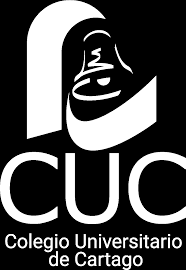
## Colegio Universitario de Cartago
## Carrera de Big Data

### Programación II
### Proyecto #1: Análisis de Sentimientos

### Estudiantes:
### Sebastián Calvo Solano
### Isaac Rodríguez Zuñiga

### Profesor: Osvaldo González Chaves

</div>

  



# Analisis de sentimientos 
Es el proceso automatizado de etiquetar datos de acuerdo al sentimiento del texto como: positivo, negativo, neutro. Es usado en compañías para detectar nuevas percepciones y conocimientos de datos en escala. En su esencia es lenguaje natural de procesamiento, una técnica para clasificar la polaridad de texto segun su sentimiento.

Permite el procesamiento de datos en escala y tiempo real, se puede automatizar esta clasificación para entender directamente como las personas hablan y opinan acerca de un tema en específico, lo que permite a organizaciones:
- Tomar acciones basada en el conocimiento adquerido a partir de los datos.
- Entender como las personas estan hablando de una marca vs competidores 
- Analizar comentarios de encuestas y reseñas de productos 
- Analizar solicitudes o reportes de errores en servicios (tickets) para evitar tasa de cancelación (churn)

## Instalación y configuración  librerías 🗃️

In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as sia
import matplotlib.pyplot as plt
from deep_translator import GoogleTranslator as ggt
import seaborn as sns
from wordcloud import WordCloud as wc
from textblob import TextBlob
import spacy  
from transformers import pipeline
import pyodbc       # DB API 2.0  
import sqlalchemy   # ORM 

## Conexion a SQL usando pyodbc 🛢

In [2]:
conexion = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=sentiment_analysis_db;"
    "Trusted_Connection=yes;"    
    "TrustServerCertificate=yes;"
)

df_sql = pd.read_sql("SELECT * FROM comentarios;",conexion)

conexion.close()    # Buena práctica 🚩

print(df_sql.shape)
print(df_sql.head())

#with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None): 
#    display(df_sql)

# Eliminar primera columna ids repetidos
comentarios = df_sql.iloc[:,1:]

(203, 4)
   id                                              texto  sentimiento  \
0   1  Excelente atención y muy buena disposición en ...          1.0   
1   2  Los productos son de alta calidad y siempre ll...          1.0   
2   3  Me encanta el diseño y la funcionalidad de la ...          1.0   
3   4  Estoy muy contento con el producto, superó mis...          1.0   
4   5  El servicio postventa fue excelente, resolvier...          1.0   

   categoria  
0          1  
1          1  
2          1  
3          1  
4          1  


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20120\464767538.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql("SELECT * FROM comentarios;",conexion)


## Extracción y Transformación: Limpieza del dataset
###  Especifico para la estructura de 'comentarios.csv'
1. with open() -> Manejar recursos eficientemente al cerrar
2. Condicionalmente se seleccionan las lineas/observaciones que empiezan con : "
3. Unión de toda la columna 'texto' usando slicing separando los ultimos dos columnas/variables
4. Creación y agregación de los objetos: 'filas' y 'columnas'

In [ ]:
filas = []

#Limpieza
# Se utiliza "latin-1" debido a que el archivo posee caracteres como tildes (á, é etc) o la letra eñe (ñ) que el tradicional utf-8 no soporta 
with open('comentarios.csv',encoding='latin1' ) as f:   # with: Context manager, cerrar el archivo 
    header = next(f)         # Salta header (primera columna de f)
    
    for linea in f:
        # .strip -> elimina espacios blanco y \n  
        linea = linea.strip()

        if linea.startswith('"'):
            linea = linea.strip(',')
            linea = linea.strip('"')
        else:
            linea = linea.strip(',')    

        parte_linea = linea.split(';')      #.split(';') separa en pedazos
        texto = ';'.join(parte_linea[:-2])          # parte_linea[:-2] desde el inicio hasta el penultimo elemento, todo excepto los ultimos 2 elementos
        #texto = ';'    
        sentimiento = parte_linea[-2].strip()
        categoria = parte_linea[-1].strip()
        filas.append([texto,sentimiento,categoria])

comentarios = pd.DataFrame(filas, columns=['texto', 'sentimiento', 'categoria'])
comentarios['sentimiento'] = pd.to_numeric(comentarios['sentimiento'], errors='coerce') # default error raise -> Exception 
comentarios['categoria']   = pd.to_numeric(comentarios['categoria'],   errors='coerce') # Invalid converts into Nan

#comentarios


#with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None): 
#    display(comentarios)

comentarios.to_csv('comentarios_limpio.csv',index=True, encoding='utf-8-sig',sep='|' )      # Exportar con nuevo separador "|" 

## TextBlob
Librerías
1. ggt -> Traductor de Google
2. TextBlob: Analisis sencillo, gran velocidad y facilidad. Disponible para idioma inglés (integración con ggt).

In [3]:
traductor = ggt(source='auto',target='en')

polaridad = []
subjetividad = []
sentimiento_tb = []

for texto in comentarios['texto']:
    traduccion = traductor.translate(texto)

    blob = TextBlob(traduccion)
    pol = blob.sentiment.polarity           # Valor númerico float [-1.0 , 1.0] Polaridad del texto negativo - positivo
    sub = blob.sentiment.subjectivity       # Valor númerico float [0.0 , 1.0]  Opinión personal: 0.0 -> hecho factico , 1.0 -> Opinión comentario

    if pol > 0:
        etiqueta = "Positivo"
    elif pol < 0:
        etiqueta = "Negativo"
    else:
        etiqueta = "Neutro"
    
    polaridad.append(pol)
    subjetividad.append(sub)
    sentimiento_tb.append(etiqueta)

comentarios['tb_polaridad'] = polaridad
comentarios['tb_subjetividad'] = subjetividad
comentarios['tb_sentimiento'] = sentimiento_tb

print(comentarios['tb_sentimiento'].value_counts())
comentarios.head(10)

tb_sentimiento
Positivo    115
Negativo     67
Neutro       21
Name: count, dtype: int64


,texto,sentimiento,categoria,tb_polaridad,tb_subjetividad,tb_sentimiento
0,Excelente atención y muy buena disposición en ...,1.0,1,0.955000,0.890000,Positivo
1,Los productos son de alta calidad y siempre ll...,1.0,1,0.405000,0.770000,Positivo
2,Me encanta el diseño y la funcionalidad de la ...,1.0,1,0.466667,0.716667,Positivo
3,"Estoy muy contento con el producto, superó mis...",1.0,1,1.000000,1.000000,Positivo
4,"El servicio postventa fue excelente, resolvier...",1.0,1,1.000000,1.000000,Positivo
5,"Muy mala experiencia con la compra, el product...",0.0,1,-0.655000,0.733333,Negativo
6,El servicio al cliente fue poco profesional y ...,0.0,1,0.000000,0.000000,Neutro
7,"Me siento decepcionado, la calidad no es como ...",0.0,1,-0.750000,0.750000,Negativo
8,Tardaron demasiado en responder y no soluciona...,0.0,1,-0.050000,0.400000,Negativo
9,"No recomendaría este servicio, tuve problemas ...",0.0,1,0.000000,0.000000,Neutro


## 🌌 Vader 🤖🪐
Librerías:
1. SentimentIntensityAnalyzer Vader as sia -> Textos informales, emojis, rrss, reseñas. Posee reglas heurísticas para lenguaje informal
2. ggt

In [4]:
analyzer = sia()
traductor = ggt(source='auto', target='en')

compound_scores = []
sentimiento_vader = []

for texto in comentarios['texto']:
    # 1. Traducir al inglés
    traduccion = traductor.translate(texto)
    
    # 2. Analizar con VADER
    scores = analyzer.polarity_scores(traduccion)
    compound = scores['compound']                   # Valor compuesto: pos, neu, neg    -> [-1.0 , 1.0]
    
    # 3. Clasificar con umbrales estándar de VADER
    if compound >= 0.05:    
        etiqueta = "Positivo"
    elif compound <= -0.05:
        etiqueta = "Negativo"
    else:
        etiqueta = "Neutro"

    compound_scores.append(compound)
    sentimiento_vader.append(etiqueta)

comentarios['vader_compound']    = compound_scores
comentarios['vader_sentimiento'] = sentimiento_vader

print(comentarios['vader_sentimiento'].value_counts())
comentarios.head(5)

vader_sentimiento
Positivo    106
Negativo     81
Neutro       16
Name: count, dtype: int64


,texto,sentimiento,categoria,tb_polaridad,tb_subjetividad,tb_sentimiento,vader_compound,vader_sentimiento
0,Excelente atención y muy buena disposición en ...,1.0,1,0.955000,0.890000,Positivo,0.8268,Positivo
1,Los productos son de alta calidad y siempre ll...,1.0,1,0.405000,0.770000,Positivo,0.4754,Positivo
2,Me encanta el diseño y la funcionalidad de la ...,1.0,1,0.466667,0.716667,Positivo,0.7964,Positivo
3,"Estoy muy contento con el producto, superó mis...",1.0,1,1.000000,1.000000,Positivo,0.6115,Positivo
4,"El servicio postventa fue excelente, resolvier...",1.0,1,1.000000,1.000000,Positivo,0.4767,Positivo


## Spacy + TextBlob
Librerías:
1. Spacy ("versión para español") -> Eliminar ruido gramatical reduciendo a lexemas/raíz (separar parte invariable que contiene el significado principal de los morfemas) 
2. Textblob -> Calculo de sentimiento 

Hasta el momento del notebook se tendría el siguiente analisis:


| TextBlob | Sentiment Intensity: AnalizerVader | Spacy + TextBlob | 
| :--- | :--- | :--- |
| tb_sentimiento | vader_sentimiento  | spacy_sentimiento |
| Positivo    115   |  Positivo    106 | Positivo    103  |
| Negativo     67   |  Negativo     81 | Negativo     65  |
| Neutro       21   |  Neutro       16 | Neutro       35  |


In [5]:
#nlp_spacy_esp = spacy.load("es_core_news_sm") -> No funcionó correctamente con TextBlob
nlp_spacy_en = spacy.load("en_core_web_sm")
traductor = ggt(source='auto', target='en')

polaridad_sp = []
subjetividad_sp = []
sentimiento_sp = []

for texto in comentarios["texto"]:
    # 
    traduccion = traductor.translate(texto)
    oracion = nlp_spacy_en(traduccion)
    #lemma: "Una sola cadena string refinada y ultra limpia"
                    # token.lemma_ -> palabra en su versión canónica o de diccionario 
                            # token -> palabra si se cumple la condición:
                                # 
    lemma = " ".join([token.lemma_ for token in oracion
                        if not token.is_stop and not token.is_punct])
                        # elimina stop words y signos de puntuación -> si cumple la condición lo une y cocatena con espacios en lemma 

# TextBlob para analizar toda la frase lemma
    blob = TextBlob(lemma)
    pol = blob.sentiment.polarity
    sub = blob.sentiment.subjectivity

    if pol > 0:
        etiqueta = "Positivo"
    elif pol < 0:
        etiqueta = "Negativo"
    else:
        etiqueta = "Neutro"

    
    polaridad_sp.append(pol)
    subjetividad_sp.append(sub)
    sentimiento_sp.append(etiqueta)

comentarios["spacy_polaridad"] = polaridad_sp
comentarios["spacy_subjetividad"] = subjetividad_sp
comentarios["spacy_sentimiento"] = sentimiento_sp

print(comentarios['spacy_sentimiento'].value_counts())

with pd.option_context('display.max_columns', None, 'display.max_rows',None, 'display.max_colwidth',None):
    display(comentarios)

c:\Users\LENOVO\anaconda3\envs\sentiment_analysis\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


spacy_sentimiento
Positivo    103
Negativo     65
Neutro       35
Name: count, dtype: int64


,texto,sentimiento,categoria,tb_polaridad,tb_subjetividad,tb_sentimiento,vader_compound,vader_sentimiento,spacy_polaridad,spacy_subjetividad,spacy_sentimiento
0,Excelente atención y muy buena disposición en el servicio. Recomendado.,1.0,1,9.550000e-01,0.890000,Positivo,0.8268,Positivo,0.850000,0.800000,Positivo
1,Los productos son de alta calidad y siempre llegan a tiempo. Muy satisfecho.,1.0,1,4.050000e-01,0.770000,Positivo,0.4754,Positivo,0.330000,0.770000,Positivo
2,Me encanta el diseño y la funcionalidad de la aplicación. Es intuitiva y fácil de usar.,1.0,1,4.666667e-01,0.716667,Positivo,0.7964,Positivo,0.466667,0.716667,Positivo
3,"Estoy muy contento con el producto, superó mis expectativas en todos los sentidos.",1.0,1,1.000000e+00,1.000000,Positivo,0.6115,Positivo,0.800000,1.000000,Positivo
4,"El servicio postventa fue excelente, resolvieron mi problema de inmediato.",1.0,1,1.000000e+00,1.000000,Positivo,0.4767,Positivo,1.000000,1.000000,Positivo
5,"Muy mala experiencia con la compra, el producto llegó en mal estado.",0.0,1,-6.550000e-01,0.733333,Negativo,-0.7841,Negativo,-0.550000,0.633333,Negativo
6,El servicio al cliente fue poco profesional y no resolvieron mis problemas.,0.0,1,0.000000e+00,0.000000,Neutro,-0.6688,Negativo,0.000000,0.000000,Neutro
7,"Me siento decepcionado, la calidad no es como la prometen en la publicidad.",0.0,1,-7.500000e-01,0.750000,Negativo,-0.6381,Negativo,-0.750000,0.750000,Negativo
8,Tardaron demasiado en responder y no solucionaron mi inconveniente.,0.0,1,-5.000000e-02,0.400000,Negativo,0.1695,Positivo,-0.050000,0.400000,Negativo
9,"No recomendaría este servicio, tuve problemas desde el principio.",0.0,1,0.000000e+00,0.000000,Neutro,-0.5873,Negativo,0.000000,0.000000,Neutro


## Transformers pipeline HuggingFace
Librerías:
1. Time (prueba de duración del modelo por línea de texto)
2. Transformers -> Pipeline


In [6]:
import time

clasificador = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

inicio = time.time()
resultado = clasificador(comentarios['texto'][0])
fin = time.time()

print(resultado)
print(f"Tiempo por frase {fin - inicio:.2f} segundos")

Device set to use cpu


[{'label': '5 stars', 'score': 0.7042403221130371}]
Tiempo por frase 0.69 segundos


In [7]:
puntuaciones = []
estrellas = []
seguridad_modelo = []

for texto in comentarios["texto"]:
    resultado = clasificador(texto)[0]
    label = resultado['label']
    stars = int(label[0])
    score = resultado['score']

    if stars <= 2:
        puntuacion = "Negativo"
    elif stars == 3:
        puntuacion = "Neutro"
    else:
        puntuacion = "Positivo"

    puntuaciones.append(puntuacion)
    estrellas.append(stars)
    seguridad_modelo.append(score)

comentarios["HF_Puntuación"] = puntuaciones
comentarios["HF_Estrellas"] = estrellas
comentarios["HF_seguridad_modelo"] = seguridad_modelo

print(comentarios["HF_Puntuación"].value_counts())

    #print(f"Resultado: {resultado}")
    #print(f"Frase: {texto}")
    #print(f"Estrellas: {stars}")
    #print(f"Puntuacion: {puntuacion}")
    #print()

HF_Puntuación
Positivo    103
Negativo     98
Neutro        2
Name: count, dtype: int64



| TextBlob | Sentiment Intensity: AnalizerVader | Spacy + TextBlob | Transformers HF |
| :--- | :--- | :--- | :--- |
| tb_sentimiento | vader_sentimiento  | spacy_sentimiento |     HF_Puntuación   |
| Positivo    115   |  Positivo    106 | Positivo    103  |     Positivo    103 |     
| Negativo     67   |  Negativo     81 | Negativo     65  |     Negativo     98 |
| Neutro       21   |  Neutro       16 | Neutro       35  |     Neutro        2 |


# GRÁFICOS

## Clasificación por modelo

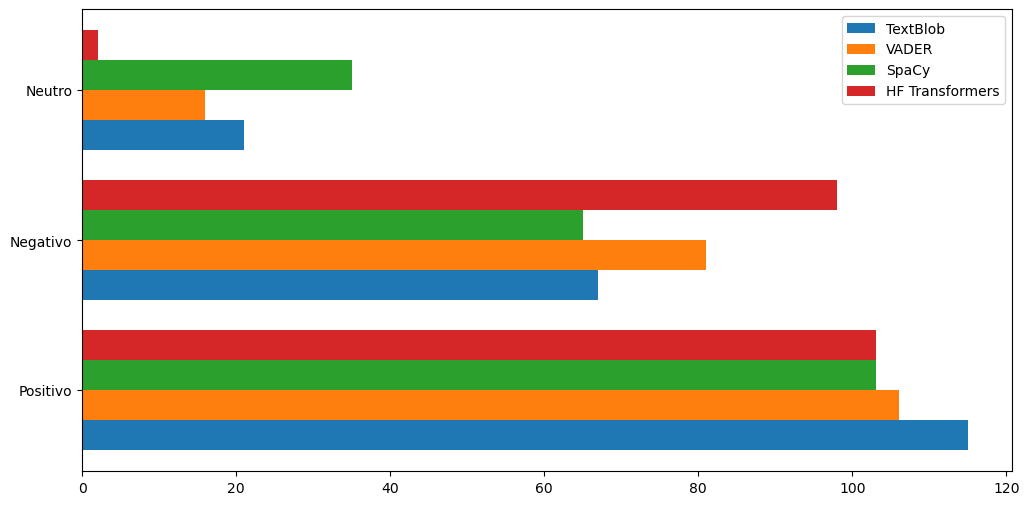

In [8]:
import matplotlib.pyplot as plt
import numpy as np

categorias = ["Positivo","Negativo","Neutro"]
textblob = [115,67,21]
vader_sia = [106,81,16]
spacy_textblob = [103,65,35]
transformers_hf = [103,98,2]


y = np.arange(len(categorias))
ancho = 0.2
pos_textblob = y - 0.3
pos_vader = y - 0.1
pos_sp = y + 0.1
pos_hf = y + 0.3

#print(f"TextBlob:  {pos_textblob}")
#print(f"VADER:     {pos_vader}")
#print(f"SpaCy:     {pos_sp}")
#print(f"HF:        {pos_hf}")

fig, ax = plt.subplots(figsize=(12,6))
ax.barh(pos_textblob, textblob, height=ancho, label="TextBlob")
ax.barh(pos_vader,    vader_sia,    height=ancho, label="VADER")
ax.barh(pos_sp,    spacy_textblob,    height=ancho, label="SpaCy")
ax.barh(pos_hf,       transformers_hf,       height=ancho, label="HF Transformers")

ax.set_yticks(y)
ax.set_yticklabels(categorias)
ax.legend()

plt.show()

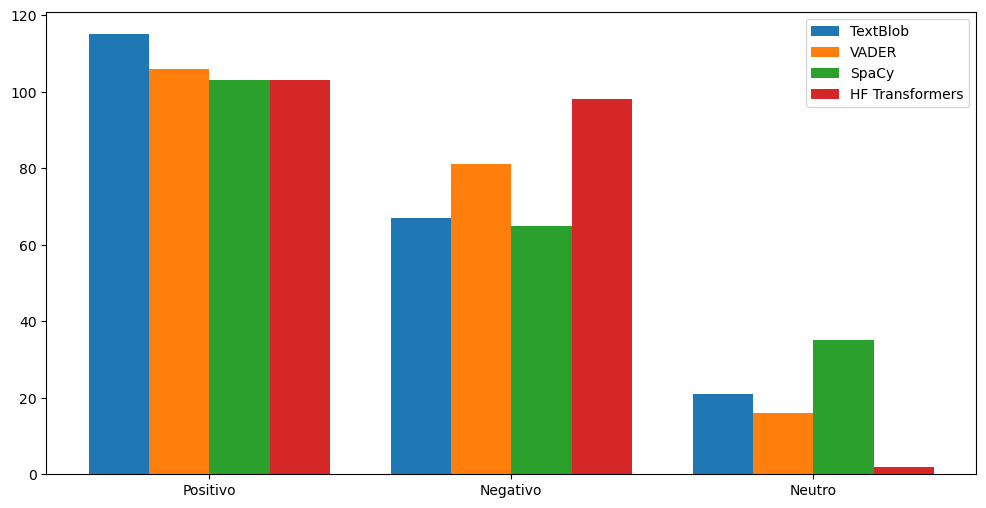

In [9]:
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(pos_textblob, textblob, width=ancho, label="TextBlob")
ax.bar(pos_vader,    vader_sia,    width=ancho, label="VADER")
ax.bar(pos_sp,    spacy_textblob,    width=ancho, label="SpaCy")
ax.bar(pos_hf,       transformers_hf,       width=ancho, label="HF Transformers")

ax.set_xticks(y)
ax.set_xticklabels(categorias)
ax.legend()

plt.show()

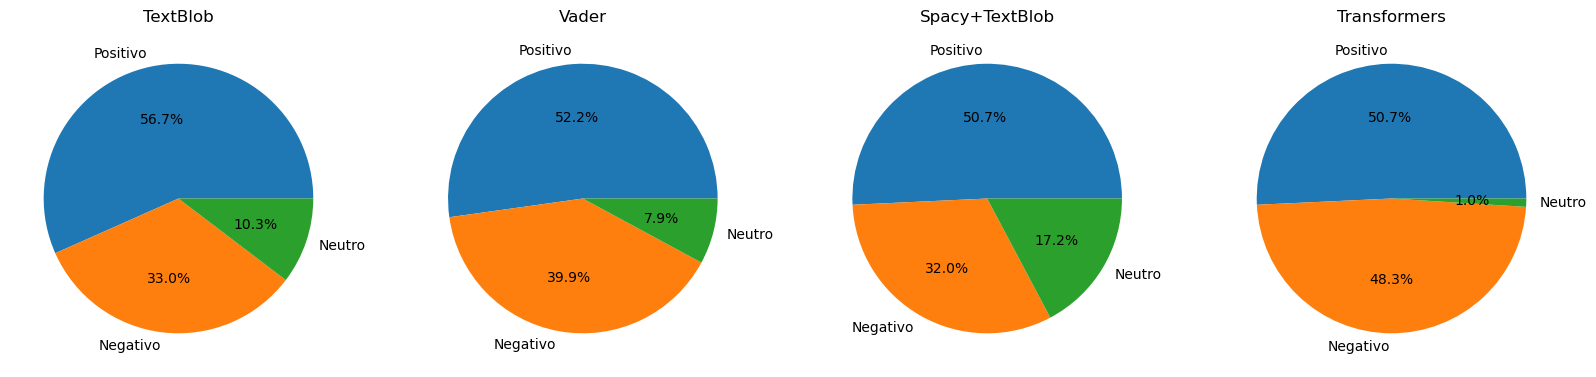

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

axes[0].pie(textblob, labels=categorias, autopct='%1.1f%%')
axes[0].set_title("TextBlob")
axes[1].pie(vader_sia, labels=categorias, autopct='%1.1f%%')
axes[1].set_title("Vader")
axes[2].pie(spacy_textblob, labels=categorias, autopct='%1.1f%%')
axes[2].set_title("Spacy+TextBlob")
axes[3].pie(transformers_hf, labels=categorias, autopct='%1.1f%%')
axes[3].set_title("Transformers")

plt.show()

## Correlaciones importantes

#### Plot 1: Correlacion de metrica (float) de cada modelo.
#### Plot 1: Correlacion de sentimiento (Positivo, Negativo, Neutro) de cada modelo.

Se observa como spacy_polaridad y tb_polaridad tienen una correlación fuerte negativa, sin embargo al analizar y clasificar los sentimientos convergen en una correlación fuerte positiva.


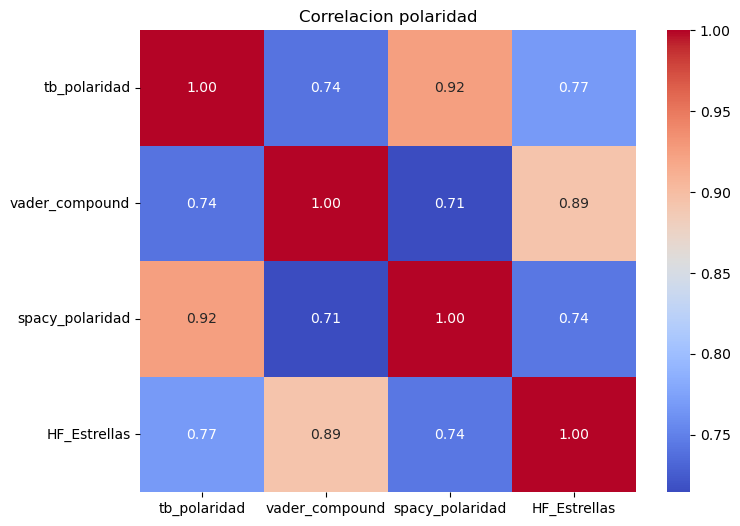

In [11]:
import seaborn as sns
#print(comentarios.head(3))

scores = comentarios[['tb_polaridad','vader_compound','spacy_polaridad','HF_Estrellas']]

correlacion = scores.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlacion,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            )

plt.title("Correlacion polaridad")
plt.show()


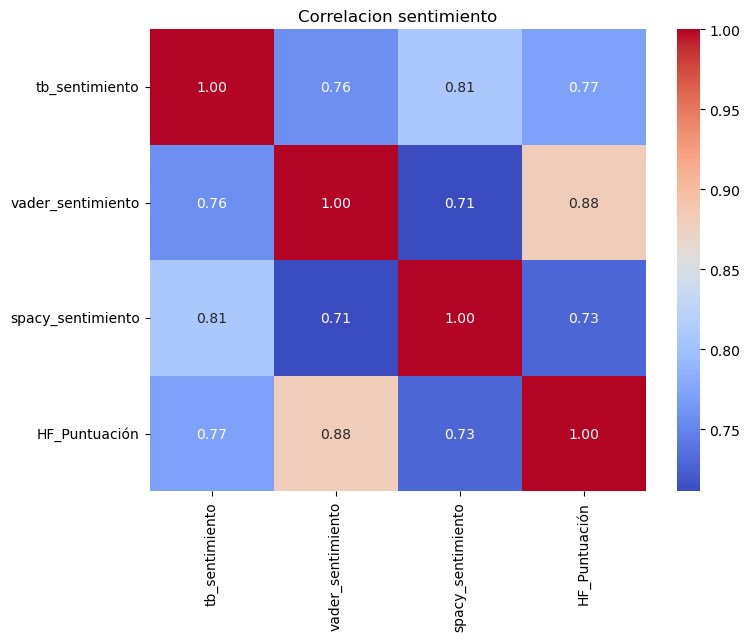

In [12]:
etiquetas = comentarios[['tb_sentimiento','vader_sentimiento','spacy_sentimiento','HF_Puntuación']]
mapeo = {"Positivo":1, "Negativo":-1, "Neutro":0}
etiquetas_mapeado = etiquetas.replace(mapeo)

correlacion_etiqueta = etiquetas_mapeado.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlacion_etiqueta,
            annot=True,
            fmt = ".2f",
            cmap="coolwarm")
plt.title("Correlacion sentimiento")
plt.show()

## Comparación de precisión contra  sentimiento valor original del csv

El modelo HuggingFace es el más preciso al sentimiento original, con un 99% de precisión 

['TextBlob', 'Vader', 'Spacy+TextBlob', 'Transformers_HF']
[0.7980295566502463, 0.8768472906403941, 0.7389162561576355, 0.9901477832512315]


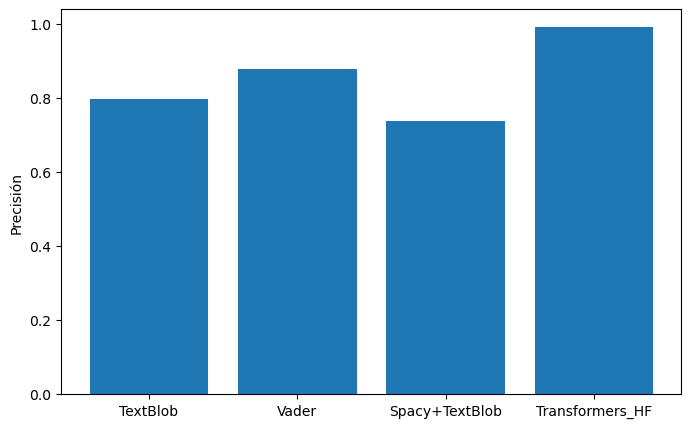

In [16]:
from sklearn.metrics import accuracy_score

mapeo_original = {1.0:"Positivo", 0.0:"Negativo"}
comentarios['sentimiento_original'] = comentarios['sentimiento'].map(mapeo_original)

acc_tb = accuracy_score(comentarios['sentimiento_original'],comentarios['tb_sentimiento'])
acc_vader = accuracy_score(comentarios['sentimiento_original'],comentarios['vader_sentimiento'])
acc_sp = accuracy_score(comentarios['sentimiento_original'],comentarios['spacy_sentimiento'])
acc_hf = accuracy_score(comentarios['sentimiento_original'],comentarios['HF_Puntuación'])


modelos = ["TextBlob" , "Vader" , "Spacy+TextBlob","Transformers_HF"]
precision = [acc_tb,acc_vader,acc_sp,acc_hf]
print(modelos)
print(precision)

plt.figure(figsize=(8,5))
plt.bar(modelos,precision)
plt.ylabel("Precisión")
plt.show()

## WordCloud -> HuggingFace Transformers pipeline 🌧

✔️ Comentarios Positivos: Asociados al aprendizaje y calidad, también con el ambiente y la atención, además de estudiante.

❌ Comentarios Negativos: Relacionados a la clase, servicioy experiencia, también con tiempo, problema y plataforma. 

Estudiante aparece en ambos grupos lo que refleja la importancia del componente educativo.

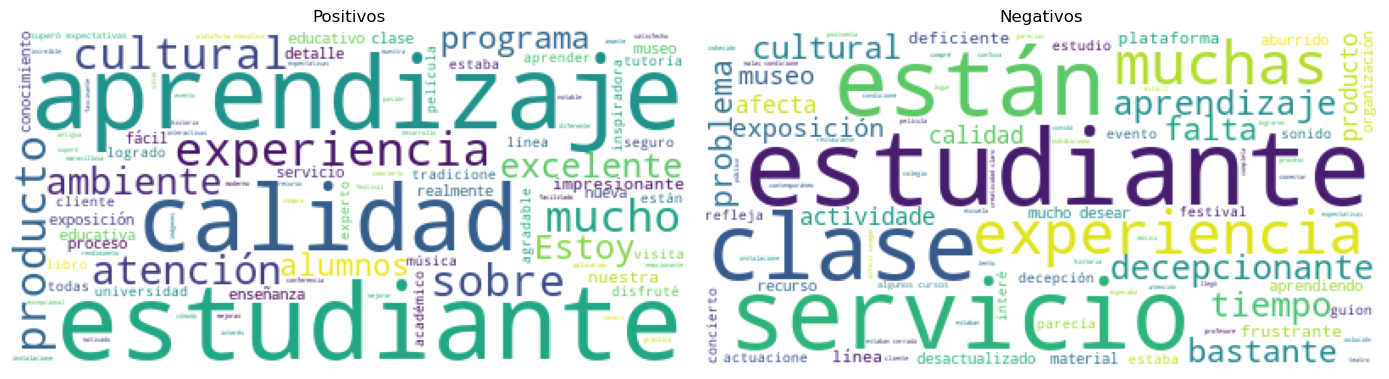

In [ ]:
from wordcloud import WordCloud as wc

HF_Positivos = comentarios[comentarios['HF_Puntuación']=='Positivo']['texto']
HF_Negativos = comentarios[comentarios['HF_Puntuación']=='Negativo']['texto']
#HF_Neutros = comentarios[comentarios['HF_Puntuación']=='Neutro']['texto'] # -> Es un 1% para HF, 2 lineas aproximadamente


# Lemma
def lemmatizar(textos):
    lemmas = []
    for texto in textos:
        doc = nlp_spacy_en(texto)
        lemma = " ".join([token.lemma_ for token in doc
                          if not token.is_stop and not token.is_punct and len(token.lemma_) > 4 and token.is_alpha
                          ])
        lemmas.append(lemma)
    return " ".join(lemmas)

textos_positivos = lemmatizar(HF_Positivos)
textos_negativos = lemmatizar(HF_Negativos)
#textos_neutros = lemmatizar(HF_Neutros)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.imshow(wc(background_color='white').generate(textos_positivos))
ax1.set_title("Positivos")
ax1.axis('off')

ax2.imshow(wc(background_color='white').generate(textos_negativos))
ax2.set_title("Negativos")
ax2.axis('off')

#ax3.imshow(wc(background_color='white').generate(textos_neutros))
#ax3.set_title("Neutros")
#ax3.axis('off')

plt.tight_layout()
plt.show()


## Bibliografía:
1. https://huggingface.co/blog/sentiment-analysis-python
2. https://vadersentiment.readthedocs.io/en/latest/pages/about_the_scoring.html  
3. https://spacy.io/models/en
4. https://huggingface.co/docs/transformers/quicktour